In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from narwhals.selectors import categorical
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
import shap
import optuna
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split

In [95]:
application_train = pd.read_csv("train_features.csv")
application_test = pd.read_csv("test_features.csv")

In [96]:
application_train.shape

(307511, 169)

In [97]:
application_test.shape

(48744, 168)

In [98]:
application_train.head()

,Unnamed: 0,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,...,max_amt_application,mean_amt_credit,max_amt_credit,mean_percentage_recieved,mean_amt_down_payment,max_amt__down_payment,prev_application_count,prev_approved,prev_refused,prev_approval_rate
0,0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,...,179055.0,179055.00,179055.0,0.999994,0.00,0.0,1.0,1.0,0.0,1.000000
1,1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,...,900000.0,484191.00,1035882.0,1.057658,3442.50,6885.0,3.0,3.0,0.0,1.000000
2,2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,...,24282.0,20106.00,20106.0,0.827987,4860.00,4860.0,1.0,1.0,0.0,1.000000
3,3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,...,688500.0,291695.50,906615.0,1.012677,34840.17,66987.0,9.0,5.0,1.0,0.555556
4,4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,...,247500.0,166638.75,284400.0,1.046339,3390.75,3676.5,6.0,6.0,0.0,1.000000


In [99]:
application_test.head()

,Unnamed: 0,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,max_amt_application,mean_amt_credit,max_amt_credit,mean_percentage_recieved,mean_amt_down_payment,max_amt__down_payment,prev_application_count,prev_approved,prev_refused,prev_approval_rate
0,0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,...,24835.5,23787.000,23787.0,0.957744,2520.0,2520.0,1.0,1.0,0.0,1.00
1,1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,...,44617.5,20076.750,40153.5,0.899929,4464.0,4464.0,2.0,1.0,0.0,0.50
2,2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,...,450000.0,146134.125,512370.0,1.052340,3375.0,6750.0,4.0,3.0,0.0,0.75
3,3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,...,130765.5,92920.500,225000.0,0.967465,3750.0,11250.0,5.0,3.0,0.0,0.60
4,4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,...,454500.0,300550.500,508495.5,1.131349,8095.5,8095.5,2.0,1.0,0.0,0.50


In [100]:
application_train.drop(columns=["Unnamed: 0"], inplace=True)
application_test.drop(columns=["Unnamed: 0"], inplace=True)

In [101]:
y = application_train["TARGET"]
X = application_train.drop("TARGET", axis=1)

In [102]:
numerical_cols = X.select_dtypes(include="number").columns.tolist()
categorical_cols = X.select_dtypes(exclude="number").columns.tolist()

In [103]:
print(len(numerical_cols))
print(len(categorical_cols))

151
16


In [104]:
categorical_cols

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

In [105]:
for col in categorical_cols:
    X[col] = X[col].astype('category')
    application_test[col] = application_test[col].astype('category')

In [106]:
import re
[col for col in X.columns if re.search(r'[^A-Za-z0-9_]', col)]

[]

In [107]:
X.dtypes[X.dtypes == 'object']

Series([], dtype: object)

In [108]:
#Probieren wir es zuerst mit einem LightGBM

In [109]:
GBM = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1,
    num_leaves=31
)
GBM.fit(X, y)

[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027829 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19880
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 163
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [110]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(GBM, X, y, cv=cv, n_jobs=-1, scoring="roc_auc")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.171942 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19813
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 163
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.103741 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_

In [111]:
scores.mean()
#Output: 0.7758985820151467

np.float64(0.7760108717014341)

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

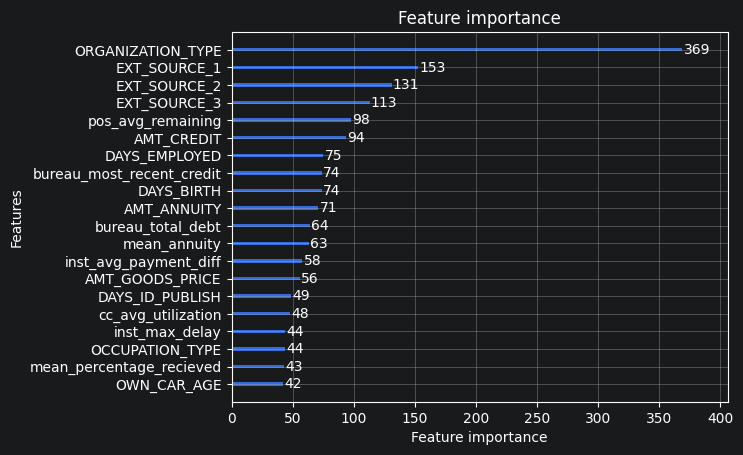

In [112]:
lgb.plot_importance(GBM, max_num_features=20)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


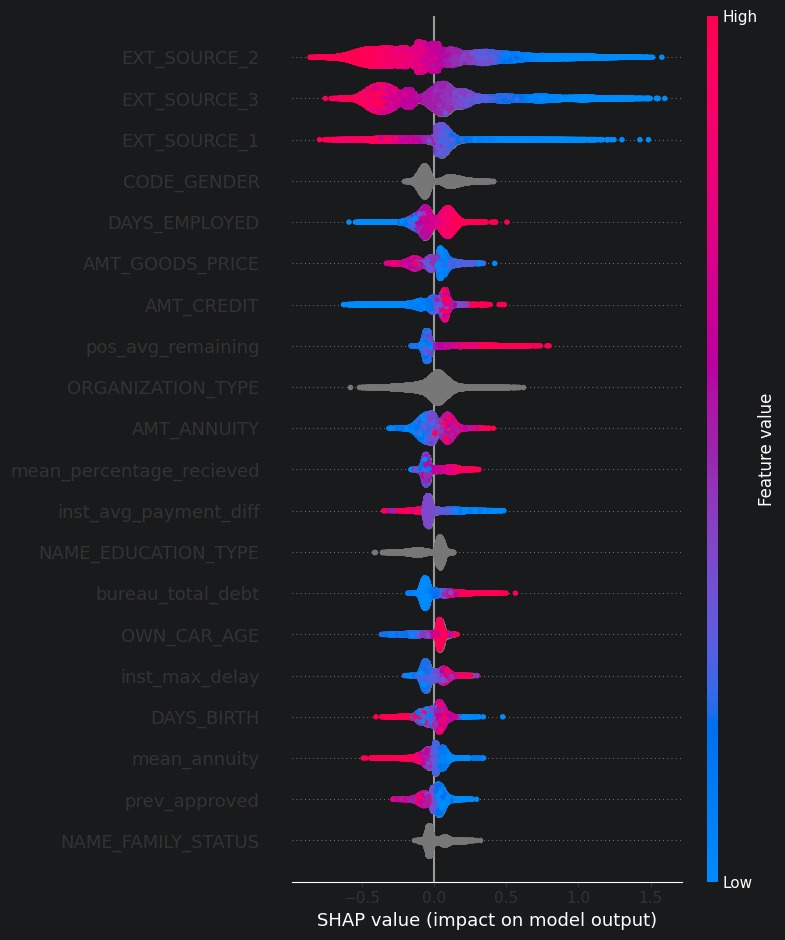

In [113]:
explainer = shap.TreeExplainer(GBM)
shap_values = explainer.shap_values(X)

# Global: welche Features sind insgesamt wichtig
shap.summary_plot(shap_values, X, max_display=20)

In [129]:
def submission(model):
    X_test = application_test.copy()
    predictions = model.predict_proba(X_test)[:, 1]  # Wahrscheinlichkeit für Klasse 1

    # Submission erstellen
    submission = pd.DataFrame({
        "SK_ID_CURR": application_test["SK_ID_CURR"],
        "TARGET": predictions
    })
    submission.to_csv("submission2.csv", index=False)
    return submission

In [115]:
#Besseres Boosting Model:

In [121]:
def objective(trial):
    params = {
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'n_estimators': 1000,  # hohes Maximum – Early Stopping stoppt früher
        'random_state': 42,
        'verbose': -1,
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    auc_scores = []

    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=-1),  # Output unterdrücken
            ]
        )

        preds = model.predict_proba(X_val)[:, 1]
        auc_scores.append(roc_auc_score(y_val, preds))

    return np.mean(auc_scores)

In [122]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print(study.best_params)
print(study.best_value)

[I 2026-05-07 15:32:42,973] A new study created in memory with name: no-name-cdaa91cf-85c6-453b-b2e5-349570645380
[I 2026-05-07 15:32:57,406] Trial 0 finished with value: 0.7663968269625087 and parameters: {'num_leaves': 194, 'learning_rate': 0.12280783328575996, 'min_child_samples': 55, 'subsample': 0.698352223848077, 'colsample_bytree': 0.7711902736266586, 'reg_alpha': 2.4054626459491544e-08, 'reg_lambda': 0.00023727030673380755}. Best is trial 0 with value: 0.7663968269625087.
[I 2026-05-07 15:33:39,376] Trial 1 finished with value: 0.7782087839177493 and parameters: {'num_leaves': 55, 'learning_rate': 0.023788488277975025, 'min_child_samples': 37, 'subsample': 0.8182417449636534, 'colsample_bytree': 0.8630469068532831, 'reg_alpha': 4.9447256945388295e-06, 'reg_lambda': 2.7656236966333967e-07}. Best is trial 1 with value: 0.7782087839177493.
[I 2026-05-07 15:34:02,111] Trial 2 finished with value: 0.7748975140448371 and parameters: {'num_leaves': 76, 'learning_rate': 0.0553975476833

{'num_leaves': 162, 'learning_rate': 0.010206450064908001, 'min_child_samples': 44, 'subsample': 0.6047720005971476, 'colsample_bytree': 0.5051817001262647, 'reg_alpha': 0.013031738042029907, 'reg_lambda': 9.522032507236931}
0.7815293985462319


In [123]:
application_train["mean_percentage_recieved"].describe()

count    290042.000000
mean          1.017685
std           0.098646
min           0.199999
25%           0.972770
50%           1.020934
75%           1.076872
max           2.000000
Name: mean_percentage_recieved, dtype: float64

In [135]:
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(X, y, test_size=0.2, random_state=42)

best_model = lgb.LGBMClassifier(**study.best_params, n_estimators=1000, random_state=42)
best_model.fit(
    X_train_final, y_train_final,
    eval_set=[(X_val_final, y_val_final)],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's binary_logloss: 0.238263


,boosting_type,'gbdt'
,num_leaves,162
,max_depth,-1
,learning_rate,0.010206450064908001
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,44


In [136]:
submission3 = submission(best_model)
submission3.to_csv("submission3.csv", index=False)

In [ ]:
#Baseline XGBoost

In [138]:
application_train.select_dtypes(exclude=["number", "category"]).columns.tolist()

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

In [139]:
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,        # Anzahl der Bäume
    learning_rate=0.05,       # Schrittweite (Eta)
    max_depth=6,              # Tiefe der Bäume
    subsample=0.8,            # Anteil der Daten pro Baum (Reihe)
    colsample_bytree=0.8,     # Anteil der Features pro Baum (Spalte)
    tree_method='hist',       # Nutzt Histogramm-Methode (viel schneller, ähnlich wie LightGBM)
    random_state=42,
    use_label_encoder=False,
    enable_categorical=True,
)

# Training mit Early Stopping
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)], # Validierung auf "unbekannten" Daten
    verbose=100
)

[0]	validation_0-logloss:0.27774


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [16:29:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[100]	validation_0-logloss:0.24257
[200]	validation_0-logloss:0.24028
[300]	validation_0-logloss:0.23977
[400]	validation_0-logloss:0.23948
[500]	validation_0-logloss:0.23951
[600]	validation_0-logloss:0.23968
[700]	validation_0-logloss:0.23972
[800]	validation_0-logloss:0.23989
[900]	validation_0-logloss:0.24012
[999]	validation_0-logloss:0.24052


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

In [140]:
submission4 = submission(xgb_model)
submission4.to_csv("submission4.csv", index=False)

In [141]:
def objectiveXGB(trial):
    params = {
        # Diese Parameter werden von Optuna optimiert
        'n_estimators': 1000,
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),

        # Wichtig für deine kategorischen Daten:
        'tree_method': 'hist',
        'enable_categorical': True,
        'random_state': 42,
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    auc_scores = []

    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = xgb.XGBClassifier(**params, early_stopping_rounds=50)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        preds = model.predict_proba(X_val)[:, 1]
        auc_scores.append(roc_auc_score(y_val, preds))

    return np.mean(auc_scores)

In [ ]:
study = optuna.create_study(direction='maximize')
study.optimize(objectiveXGB, n_trials=20)
print("Beste Parameter:", study.best_params)

[I 2026-05-07 16:35:11,810] A new study created in memory with name: no-name-de4b65b7-befb-43c6-a7ee-cd439a66ef4d
[I 2026-05-07 16:35:35,048] Trial 0 finished with value: 0.7694459994516896 and parameters: {'max_depth': 9, 'learning_rate': 0.14086510516310025, 'subsample': 0.9253660841623961, 'colsample_bytree': 0.7608492158796223, 'min_child_weight': 11, 'gamma': 0.0006090235652629393}. Best is trial 0 with value: 0.7694459994516896.
[I 2026-05-07 16:37:11,533] Trial 1 finished with value: 0.7804405347640047 and parameters: {'max_depth': 6, 'learning_rate': 0.03827035119884202, 'subsample': 0.9409208133570552, 'colsample_bytree': 0.7617531052800963, 'min_child_weight': 8, 'gamma': 0.005031009494677236}. Best is trial 1 with value: 0.7804405347640047.
[I 2026-05-07 16:39:11,514] Trial 2 finished with value: 0.7808446900986494 and parameters: {'max_depth': 3, 'learning_rate': 0.05145759551484317, 'subsample': 0.9731235639897446, 'colsample_bytree': 0.9502076641736201, 'min_child_weight'